In [1]:
import os

SAVE_IMAGE_DIR = "/content/drive/MyDrive/processed_updtrain2017"
SAVE_MASK_DIR = "/content/drive/MyDrive/processed_mask_train2017"

os.makedirs(SAVE_IMAGE_DIR, exist_ok=True)
os.makedirs(SAVE_MASK_DIR, exist_ok=True)

In [2]:
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/zips/val2017.zip

--2025-12-02 04:55:24--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.182.65.81, 3.5.0.126, 16.15.183.29, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.182.65.81|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  95.4MB/s    in 2.5s    

2025-12-02 04:55:27 (95.4 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]

--2025-12-02 04:55:27--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.182.65.81, 3.5.0.126, 16.15.183.29, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.182.65.81|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017

In [3]:
!unzip -qq train2017.zip -d train2017
!unzip -qq val2017.zip -d val2017
!unzip -qq annotations_trainval2017.zip -d annotations

In [4]:
from google.colab import drive
drive.mount('/content/drive')

IMG_DIR = "/content/drive/MyDrive/processed_updtrain2017"
MASK_DIR = "/content/drive/MyDrive/binary_masking_train2017"
checkpoint_path = "/content/drive/MyDrive/pretrained_unet_checkpoint.pth"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

# Set these for each new batch
N = 10000        # Batch size
skip = 38000        # Change to 0, 1000, 2000, ... for incremental training

all_pairs = []
for mask_name in sorted(os.listdir(MASK_DIR)):
    if mask_name.endswith('.png'):
        img_name = mask_name.replace('.png', '.jpg')
        img_path = os.path.join(IMG_DIR, img_name)
        mask_path = os.path.join(MASK_DIR, mask_name)
        if os.path.exists(img_path):
            all_pairs.append((img_path, mask_path))

batch_pairs = all_pairs[skip: skip+N]
img_file_list, mask_file_list = zip(*batch_pairs)


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import torchvision.transforms as T

class SegmentationPairedDataset(Dataset):
    def __init__(self, img_files, mask_files):
        self.img_files = img_files
        self.mask_files = mask_files
        self.transform_img = T.Compose([T.Resize((224,224)), T.ToTensor()])
        self.transform_mask = T.Compose([T.Resize((224,224)), T.ToTensor()])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        image = Image.open(self.img_files[idx]).convert('RGB')
        mask = Image.open(self.mask_files[idx]).convert('L')
        image = self.transform_img(image)
        mask = self.transform_mask(mask)
        mask = (mask > 0.5).float()
        return image, mask


In [7]:
def iou_score(y_pred, y_true, smooth=1e-6):
    y_pred = (y_pred > 0.5).float()
    y_true = (y_true > 0.5).float()
    intersection = (y_pred * y_true).sum()
    union = y_pred.sum() + y_true.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()


In [8]:
!pip install -U segmentation-models-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.6 MB/s eta 0:00:00


In [9]:
import segmentation_models_pytorch as smp
import torch.nn as nn

device = torch.device('cpu')  # Use "cuda" if GPU is available

model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

# *** UNFREEZE ENCODER for full fine-tuning ***
for param in model.encoder.parameters():
    param.requires_grad = True

model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [10]:
# Step: Define and instantiate dataset and dataloaders BEFORE training loop!
dataset = SegmentationPairedDataset(img_file_list, mask_file_list)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)


Resuming from epoch 47
Epoch 48, Batch 0/600
Epoch 48, Batch 10/600
Epoch 48, Batch 20/600
Epoch 48, Batch 30/600
Epoch 48, Batch 40/600
Epoch 48, Batch 50/600
Epoch 48, Batch 60/600
Epoch 48, Batch 70/600
Epoch 48, Batch 80/600
Epoch 48, Batch 90/600
Epoch 48, Batch 100/600
Epoch 48, Batch 110/600
Epoch 48, Batch 120/600
Epoch 48, Batch 130/600
Epoch 48, Batch 140/600
Epoch 48, Batch 150/600
Epoch 48, Batch 160/600
Epoch 48, Batch 170/600
Epoch 48, Batch 180/600
Epoch 48, Batch 190/600
Epoch 48, Batch 200/600
Epoch 48, Batch 210/600
Epoch 48, Batch 220/600
Epoch 48, Batch 230/600
Epoch 48, Batch 240/600
Epoch 48, Batch 250/600
Epoch 48, Batch 260/600
Epoch 48, Batch 270/600
Epoch 48, Batch 280/600
Epoch 48, Batch 290/600
Epoch 48, Batch 300/600
Epoch 48, Batch 310/600
Epoch 48, Batch 320/600
Epoch 48, Batch 330/600
Epoch 48, Batch 340/600
Epoch 48, Batch 350/600
Epoch 48, Batch 360/600
Epoch 48, Batch 370/600
Epoch 48, Batch 380/600
Epoch 48, Batch 390/600
Epoch 48, Batch 400/600
Epoc

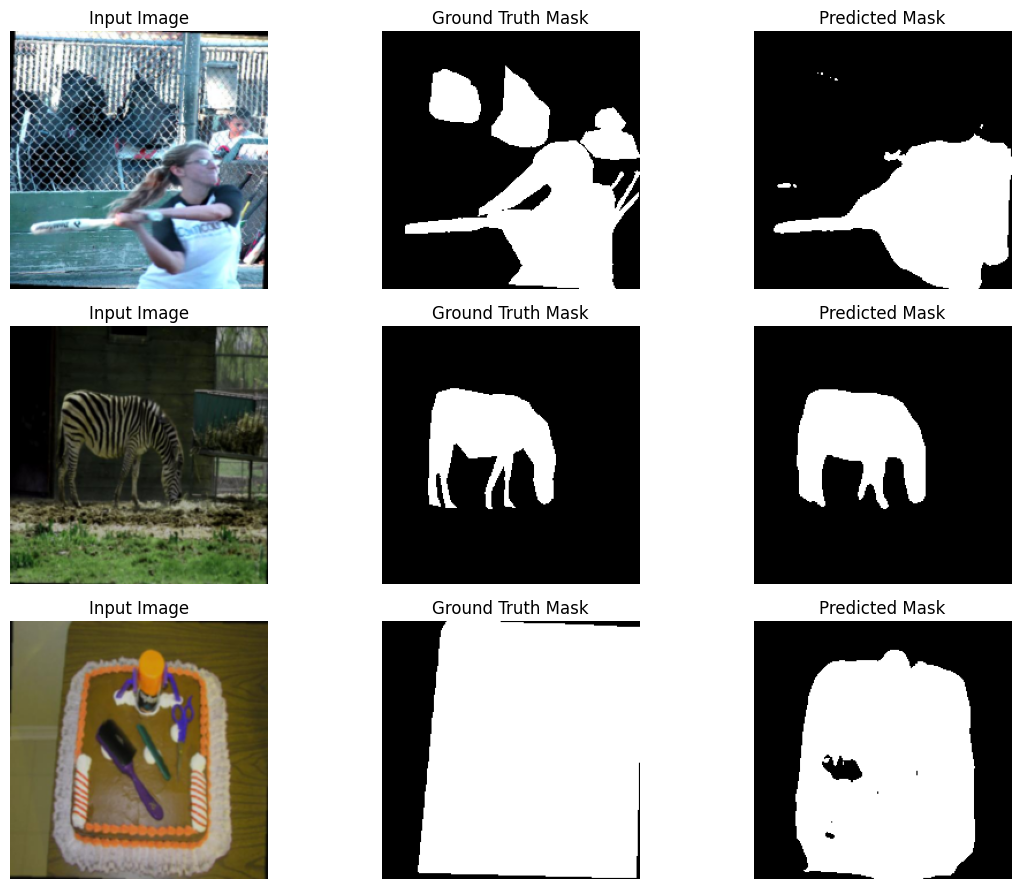

KeyboardInterrupt: 

In [ ]:
import os
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

start_epoch = 0
num_new_epochs = 10  # Number of epochs per training batch

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found, starting fresh.")

num_epochs = start_epoch + num_new_epochs

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    plt.figure(figsize=(12, num_samples * 3))
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            preds = torch.sigmoid(preds)
            preds = (preds > 0.5).float().cpu()
            images, masks = images.cpu(), masks.cpu()
            for i in range(images.size(0)):
                if shown >= num_samples:
                    break
                plt.subplot(num_samples, 3, shown*3 + 1)
                plt.imshow(images[i].permute(1, 2, 0))
                plt.title("Input Image")
                plt.axis('off')
                plt.subplot(num_samples, 3, shown*3 + 2)
                plt.imshow(masks[i][0], cmap='gray')
                plt.title("Ground Truth Mask")
                plt.axis('off')
                plt.subplot(num_samples, 3, shown*3 + 3)
                plt.imshow(preds[i][0], cmap='gray')
                plt.title("Predicted Mask")
                plt.axis('off')
                shown += 1
            if shown >= num_samples:
                break
    plt.tight_layout()
    plt.show()

for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (images, masks) in enumerate(train_loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}")
    train_loss /= len(train_loader)

    model.eval()
    val_loss, val_iou = 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            val_loss += criterion(preds, masks).item()
            val_iou += iou_score(torch.sigmoid(preds), masks)
    val_loss /= len(val_loader)
    val_iou /= len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}")

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    torch.save(checkpoint, checkpoint_path)

    # Show results every 2 epochs
    if (epoch + 1) % 2 == 0:
        print(f"Visualizing predictions after epoch {epoch+1}")
        visualize_predictions(model, val_loader, device, num_samples=3)



In [ ]:
import os
import matplotlib.pyplot as plt
import torch

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

# Correct way: Remove 'verbose'
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2  # NO verbose
)

start_epoch = 0
num_new_epochs = 6  # Number of epochs per training batch

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found, starting fresh.")

num_epochs = start_epoch + num_new_epochs

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    plt.figure(figsize=(12, num_samples * 3))
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            preds = torch.sigmoid(preds)
            preds = (preds > 0.5).float().cpu()
            images, masks = images.cpu(), masks.cpu()
            for i in range(images.size(0)):
                if shown >= num_samples:
                    break
                plt.subplot(num_samples, 3, shown*3 + 1)
                plt.imshow(images[i].permute(1, 2, 0))
                plt.title("Input Image")
                plt.axis('off')
                plt.subplot(num_samples, 3, shown*3 + 2)
                plt.imshow(masks[i][0], cmap='gray')
                plt.title("Ground Truth Mask")
                plt.axis('off')
                plt.subplot(num_samples, 3, shown*3 + 3)
                plt.imshow(preds[i][0], cmap='gray')
                plt.title("Predicted Mask")
                plt.axis('off')
                shown += 1
            if shown >= num_samples:
                break
    plt.tight_layout()
    plt.show()

def accuracy_score(y_pred, y_true):
    y_pred = (y_pred > 0.5).float()
    y_true = (y_true > 0.5).float()
    correct = (y_pred == y_true).float().sum()
    total = torch.numel(y_true)
    return (correct / total).item()

for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (images, masks) in enumerate(train_loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}")
    train_loss /= len(train_loader)

    model.eval()
    val_loss, val_iou, val_acc = 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            val_loss += criterion(preds, masks).item()
            preds_sigmoid = torch.sigmoid(preds)
            val_iou += iou_score(preds_sigmoid, masks)
            val_acc += accuracy_score(preds_sigmoid, masks)
    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_acc /= len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}, Val Acc: {val_acc:.4f}")

    scheduler.step(val_iou)
    print("Current learning rate:", optimizer.param_groups[0]['lr'])

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    torch.save(checkpoint, checkpoint_path)

    # Show results every 2 epochs
    if (epoch + 1) % 2 == 0:
        print(f"Visualizing predictions after epoch {epoch+1}")
        visualize_predictions(model, val_loader, device, num_samples=3)


Resuming from epoch 52
Epoch 53, Batch 0/2000
Epoch 53, Batch 10/2000
Epoch 53, Batch 20/2000
Epoch 53, Batch 30/2000
Epoch 53, Batch 40/2000
Epoch 53, Batch 50/2000
Epoch 53, Batch 60/2000
Epoch 53, Batch 70/2000
Epoch 53, Batch 80/2000
Epoch 53, Batch 90/2000
Epoch 53, Batch 100/2000
Epoch 53, Batch 110/2000
Epoch 53, Batch 120/2000
Epoch 53, Batch 130/2000
Epoch 53, Batch 140/2000
Epoch 53, Batch 150/2000
Epoch 53, Batch 160/2000
Epoch 53, Batch 170/2000
Epoch 53, Batch 180/2000
Epoch 53, Batch 190/2000
Epoch 53, Batch 200/2000
Epoch 53, Batch 210/2000
Epoch 53, Batch 220/2000
Epoch 53, Batch 230/2000
Epoch 53, Batch 240/2000
Epoch 53, Batch 250/2000
Epoch 53, Batch 260/2000
Epoch 53, Batch 270/2000
Epoch 53, Batch 280/2000
Epoch 53, Batch 290/2000
Epoch 53, Batch 300/2000
Epoch 53, Batch 310/2000
Epoch 53, Batch 320/2000
Epoch 53, Batch 330/2000
Epoch 53, Batch 340/2000
Epoch 53, Batch 350/2000
Epoch 53, Batch 360/2000
Epoch 53, Batch 370/2000
Epoch 53, Batch 380/2000
Epoch 53, Bat

Saving 000000000034.jpg to 000000000034 (1).jpg
Saving download.jpg to download (1).jpg
Saving download-1.jpeg to download-1 (1).jpeg
Saving download-4.jpeg to download-4 (1).jpeg
Saving download-6.jpeg to download-6 (1).jpeg
Saving downloads-2.jpg to downloads-2 (1).jpg
Saving engine.jpeg to engine (1).jpeg
Sigmoid min/max: 0.0000 / 0.9999


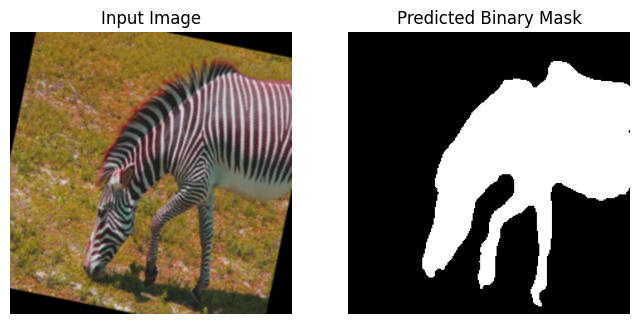

Sigmoid min/max: 0.0000 / 0.9999


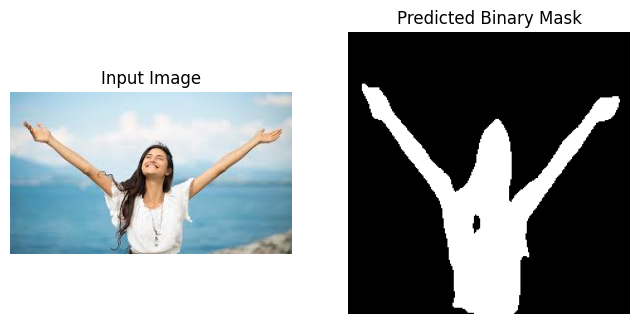

Sigmoid min/max: 0.0000 / 0.9989


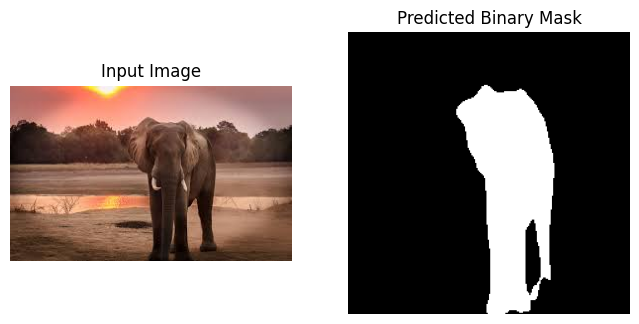

Sigmoid min/max: 0.0001 / 0.9995


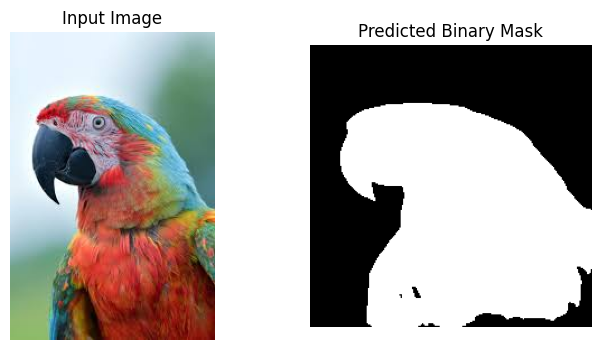

Sigmoid min/max: 0.0001 / 0.9992


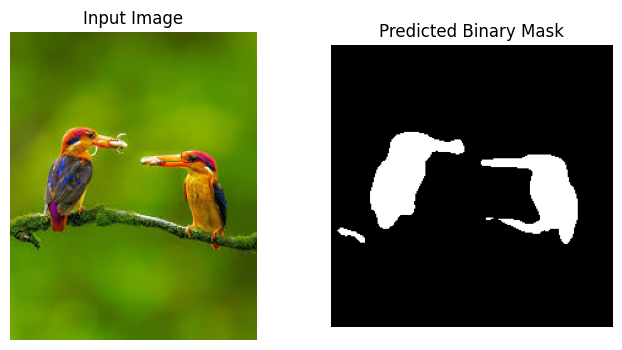

Sigmoid min/max: 0.0000 / 0.9961


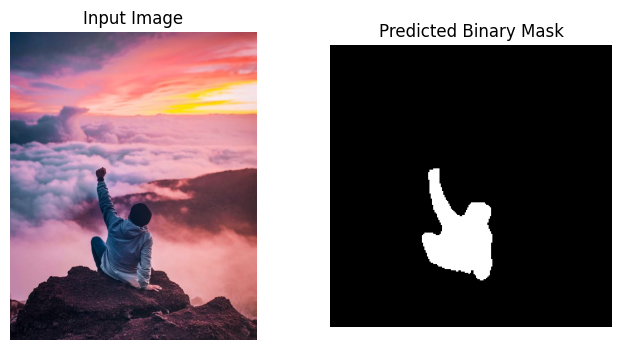

Sigmoid min/max: 0.0000 / 0.9995


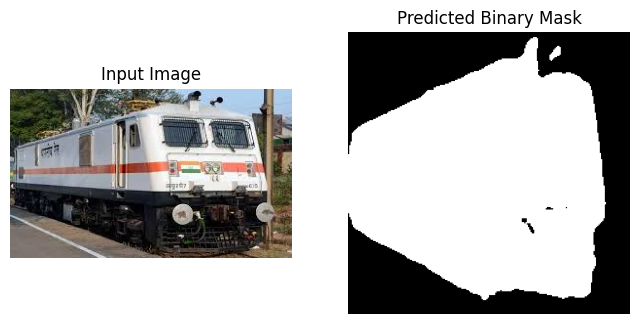

In [14]:
from PIL import Image
import torchvision.transforms as T
import torch
import matplotlib.pyplot as plt
from google.colab import files


# Device and model setup assumed already done (as per your code snippet)
# model = ...
# device = ...
# checkpoint loading code assumed done


# Preprocessing transform (same as training)
preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])


def predict_binary_mask_from_pil(pil_img, threshold=0.5):
    img_t = preprocess(pil_img)           # [3, 224, 224]
    x = img_t.unsqueeze(0).to(device)     # [1, 3, 224, 224]

    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)
        print(f"Sigmoid min/max: {float(probs.min()):.4f} / {float(probs.max()):.4f}")
        mask = (probs > threshold).float()[0, 0].cpu()   # [224, 224], binary mask

    return mask


# Upload files and display binary masks
uploaded = files.upload()   # multiple files supported

for fname in uploaded.keys():
    pil_img = Image.open(fname).convert("RGB")
    binary_mask = predict_binary_mask_from_pil(pil_img, threshold=0.5)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.title("Input Image")
    plt.imshow(pil_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Predicted Binary Mask")
    plt.imshow(binary_mask, cmap='gray')
    plt.axis("off")

    plt.show()


Resuming from epoch 61
Epoch 62, Batch 0/1000
Epoch 62, Batch 10/1000
Epoch 62, Batch 20/1000
Epoch 62, Batch 30/1000
Epoch 62, Batch 40/1000
Epoch 62, Batch 50/1000
Epoch 62, Batch 60/1000
Epoch 62, Batch 70/1000
Epoch 62, Batch 80/1000
Epoch 62, Batch 90/1000
Epoch 62, Batch 100/1000
Epoch 62, Batch 110/1000
Epoch 62, Batch 120/1000
Epoch 62, Batch 130/1000
Epoch 62, Batch 140/1000
Epoch 62, Batch 150/1000
Epoch 62, Batch 160/1000
Epoch 62, Batch 170/1000
Epoch 62, Batch 180/1000
Epoch 62, Batch 190/1000
Epoch 62, Batch 200/1000
Epoch 62, Batch 210/1000
Epoch 62, Batch 220/1000
Epoch 62, Batch 230/1000
Epoch 62, Batch 240/1000
Epoch 62, Batch 250/1000
Epoch 62, Batch 260/1000
Epoch 62, Batch 270/1000
Epoch 62, Batch 280/1000
Epoch 62, Batch 290/1000
Epoch 62, Batch 300/1000
Epoch 62, Batch 310/1000
Epoch 62, Batch 320/1000
Epoch 62, Batch 330/1000
Epoch 62, Batch 340/1000
Epoch 62, Batch 350/1000
Epoch 62, Batch 360/1000
Epoch 62, Batch 370/1000
Epoch 62, Batch 380/1000
Epoch 62, Bat

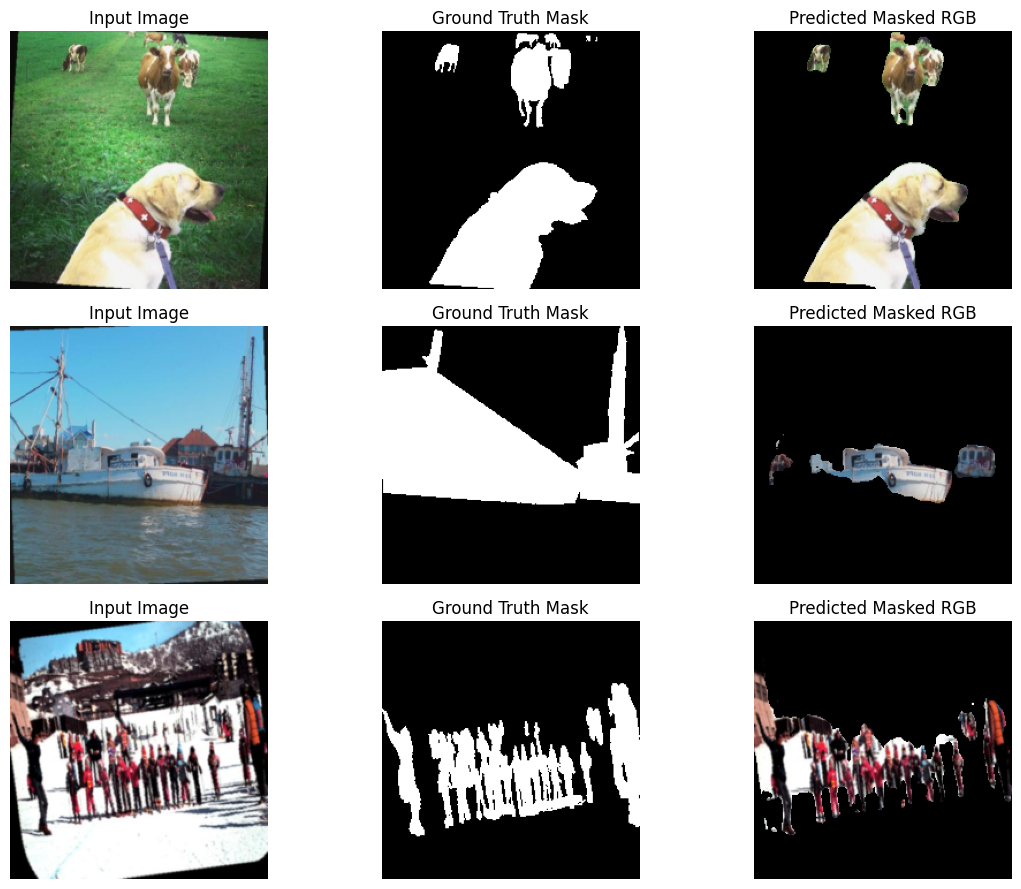

Epoch 63, Batch 0/1000
Epoch 63, Batch 10/1000
Epoch 63, Batch 20/1000
Epoch 63, Batch 30/1000
Epoch 63, Batch 40/1000
Epoch 63, Batch 50/1000
Epoch 63, Batch 60/1000
Epoch 63, Batch 70/1000
Epoch 63, Batch 80/1000
Epoch 63, Batch 90/1000
Epoch 63, Batch 100/1000
Epoch 63, Batch 110/1000


KeyboardInterrupt: 

In [11]:
import os
import matplotlib.pyplot as plt
import torch

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.BCEWithLogitsLoss()

# Automatic learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

start_epoch = 0
num_new_epochs = 3  # Number of epochs per training batch

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found, starting fresh.")

num_epochs = start_epoch + num_new_epochs

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    plt.figure(figsize=(12, num_samples * 3))
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            preds_sigmoid = torch.sigmoid(preds)
            preds_bin = (preds_sigmoid > 0.5).float()

            # Move to CPU for plotting
            images_cpu = images.cpu()
            masks_cpu = masks.cpu()
            preds_bin_cpu = preds_bin.cpu()

            # Create RGB masked image: original RGB where mask==1, black where mask==0
            # images_cpu: [B, 3, H, W], preds_bin_cpu: [B, 1, H, W]
            masked_rgb = images_cpu * preds_bin_cpu  # broadcast along channel dim

            for i in range(images_cpu.size(0)):
                if shown >= num_samples:
                    break

                # Original image
                plt.subplot(num_samples, 3, shown*3 + 1)
                plt.imshow(images_cpu[i].permute(1, 2, 0))
                plt.title("Input Image")
                plt.axis('off')

                # Ground truth mask
                plt.subplot(num_samples, 3, shown*3 + 2)
                plt.imshow(masks_cpu[i][0], cmap='gray')
                plt.title("Ground Truth Mask")
                plt.axis('off')

                # RGB image with background black (predicted mask)
                plt.subplot(num_samples, 3, shown*3 + 3)
                plt.imshow(masked_rgb[i].permute(1, 2, 0))
                plt.title("Predicted Masked RGB")
                plt.axis('off')

                shown += 1

            if shown >= num_samples:
                break

    plt.tight_layout()
    plt.show()

def accuracy_score(y_pred, y_true):
    y_pred = (y_pred > 0.5).float()
    y_true = (y_true > 0.5).float()
    correct = (y_pred == y_true).float().sum()
    total = torch.numel(y_true)
    return (correct / total).item()

for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (images, masks) in enumerate(train_loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}")
    train_loss /= len(train_loader)

    model.eval()
    val_loss, val_iou, val_acc = 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            val_loss += criterion(preds, masks).item()
            preds_sigmoid = torch.sigmoid(preds)
            val_iou += iou_score(preds_sigmoid, masks)
            val_acc += accuracy_score(preds_sigmoid, masks)
    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_acc /= len(val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Val IoU: {val_iou:.4f}, Val Acc: {val_acc:.4f}")

    scheduler.step(val_iou)
    print("Current learning rate:", optimizer.param_groups[0]['lr'])

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    torch.save(checkpoint, checkpoint_path)

    # Visualize AFTER EVERY EPOCH now
    print(f"Visualizing predictions after epoch {epoch+1}")
    visualize_predictions(model, val_loader, device, num_samples=3)


In [12]:
import torch
import segmentation_models_pytorch as smp
import torchvision.transforms as T
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Recreate the SAME model architecture
model = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,   # important: you are now loading your own weights
    in_channels=3,
    classes=1,
    activation=None
).to(device)

# 2) Load directly from your latest checkpoint
checkpoint_path = "/content/drive/MyDrive/pretrained_unet_checkpoint.pth"  # <-- put your real file here
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# 3) Preprocessing exactly as in SegmentationPairedDataset
preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

def predict_masked_rgb_from_pil(pil_img, threshold=0.5):
    img_t = preprocess(pil_img)                  # [3,224,224]
    x = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs  = torch.sigmoid(logits)
        print("Sigmoid min/max:", float(probs.min()), float(probs.max()))
        mask   = (probs > threshold).float()[0, 0].cpu()   # [224,224]

    masked = img_t * mask.unsqueeze(0)           # [3,224,224]
    masked = masked.clamp(0, 1)

    orig_np   = img_t.permute(1, 2, 0).cpu().numpy()
    masked_np = masked.permute(1, 2, 0).cpu().numpy()
    return orig_np, masked_np


Saving 000000000034.jpg to 000000000034.jpg
Saving download.jpg to download.jpg
Saving download-1.jpeg to download-1.jpeg
Saving download-4.jpeg to download-4.jpeg
Saving download-6.jpeg to download-6.jpeg
Saving downloads-2.jpg to downloads-2.jpg
Saving engine.jpeg to engine.jpeg
Sigmoid min/max: 7.922479339228516e-11 0.9999192953109741


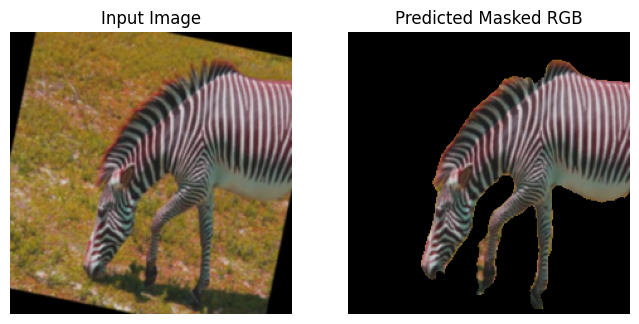

Sigmoid min/max: 6.909518788233981e-07 0.9998916387557983


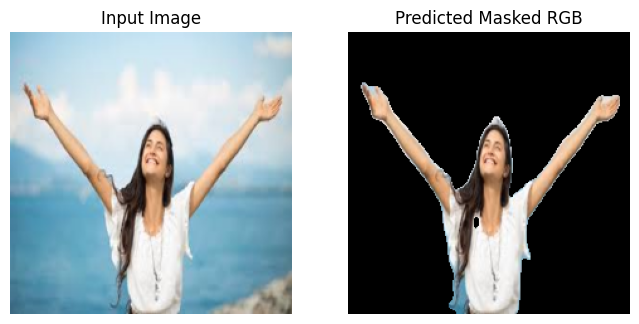

Sigmoid min/max: 8.759390084378538e-07 0.9989401698112488


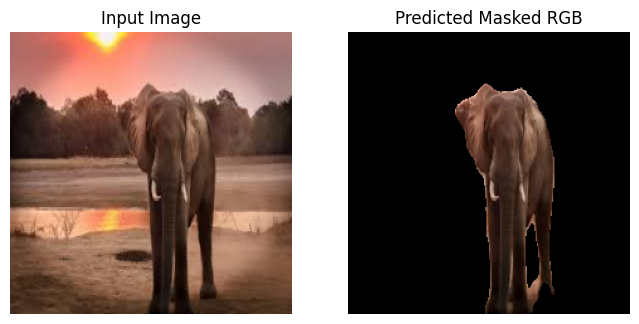

Sigmoid min/max: 0.0001250240602530539 0.9995369911193848


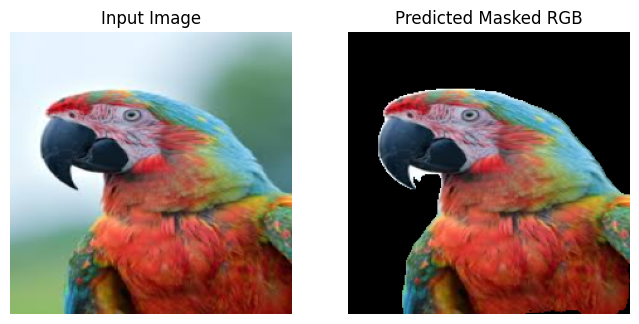

Sigmoid min/max: 5.6133932957891375e-05 0.9992014765739441


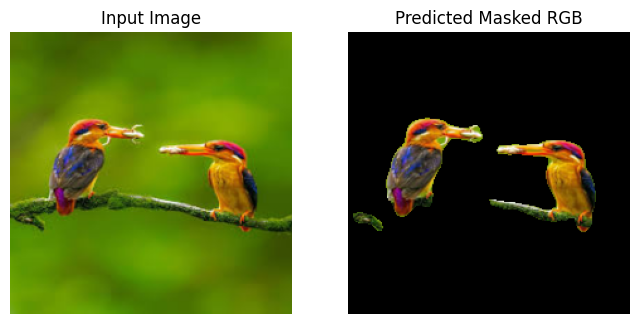

Sigmoid min/max: 2.8171057153691947e-10 0.9960508942604065


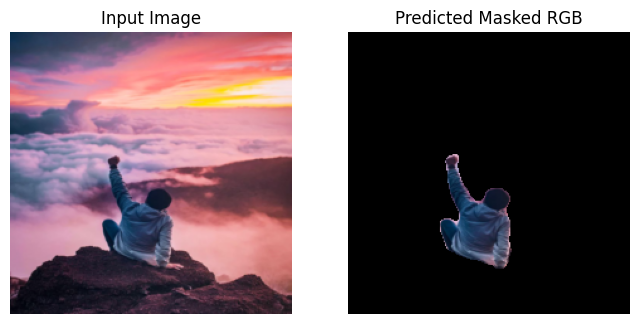

Sigmoid min/max: 1.4971150221754215e-06 0.9995347261428833


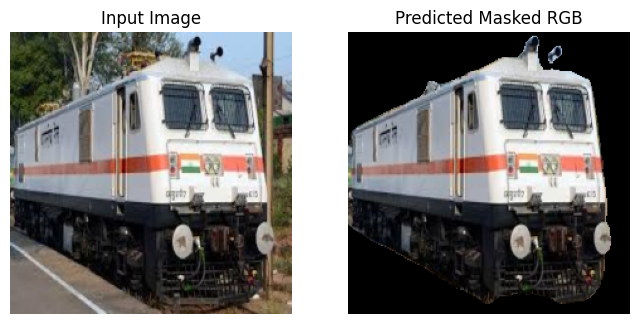

In [13]:
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()   # user picks image
for fname in uploaded.keys():
    pil_img = Image.open(fname).convert("RGB")
    orig_np, masked_np = predict_masked_rgb_from_pil(pil_img, threshold=0.3)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.title("Input Image"); plt.imshow(orig_np); plt.axis("off")
    plt.subplot(1,2,2); plt.title("Predicted Masked RGB"); plt.imshow(masked_np); plt.axis("off")
    plt.show()